In [24]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./gaussians/output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = True

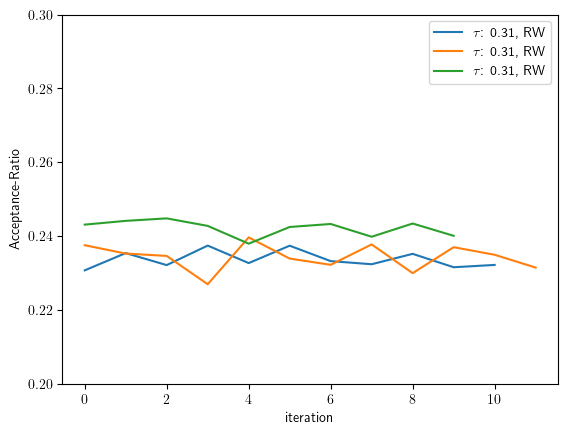

In [25]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'rw' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)
labels=["RW", "AR"]
for _idx, l in enumerate([list_idx_rwmh, list_idx_ar]):
    for idx in l:
        plt.plot(np.mean(PKLs[idx]['res'][4], axis=[0, 2, 3]), label=rf"$\tau$: {str(PKLs[idx]['config']['tau'])[:4]}, {labels[_idx]}")
plt.ylabel("Acceptance-Ratio")
plt.xlabel("iteration")
plt.ylim(0.2, 0.3)
plt.legend()
plt.savefig(DIR+"AR.png")


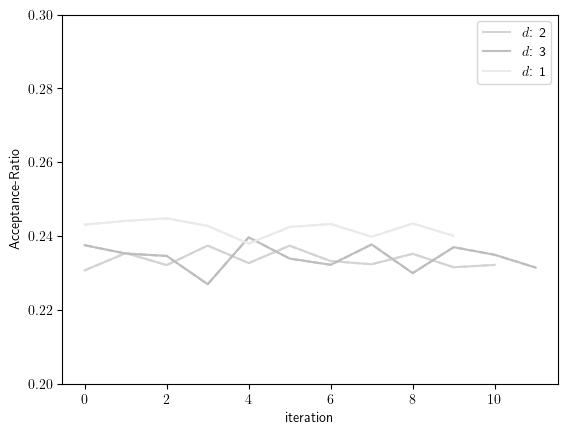

In [38]:
grays = [
    "#EAEAEA",  # Lightest gray
    "#D4D4D4",
    "#BEBEBE",
    "#A8A8A8",
    "#929292",
    "#7C7C7C",
    "#666666",
    "#505050",
    "#3A3A3A",
    "#242424"   # Darkest gray
]
for idx in range(n):
    plt.plot(np.mean(PKLs[idx]['res'][4], axis=[2, 3]).T, linestyle="--", color=grays[PKLs[idx]['config']['dim']-1])
    plt.plot(np.mean(PKLs[idx]['res'][4], axis=[0, 2, 3]).T, linestyle="solid", color=grays[PKLs[idx]['config']['dim']-1], label=rf"$d$: {str(PKLs[idx]['config']['dim'])}")
plt.ylabel("Acceptance-Ratio")
plt.xlabel("iteration")
plt.ylim(0.2, 0.3)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.savefig(DIR+"AR_rwm_across_dim.png")